
# Importing the required libraries


Install and import libraries you need (pandas for data, matplotlib/seaborn for plots, scikit-learn for models and preprocessing, statsmodels for statistical summary).

In [ ]:
# Import essential libraries
import pandas as pd                     # For data manipulation
import numpy as np                      # For numerical operations
import seaborn as sns                   # For beautiful visualizations
import matplotlib.pyplot as plt         # For custom plotting

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set Seaborn style for prettier plots
sns.set(style="whitegrid", palette="pastel")

# Show all columns while printing DataFrames
pd.set_option('display.max_columns', None)


#Loading the data

In [ ]:
# replace 'data.csv' with your Kaggle file
df = pd.read_csv('/content/healthcare_dataset.csv.zip')

In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# Quick Data Checks

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
df.shape

(55500, 15)

In [ ]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [ ]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

# Data Visualization to Find Patterns and trends in data

# Distribution of Ages

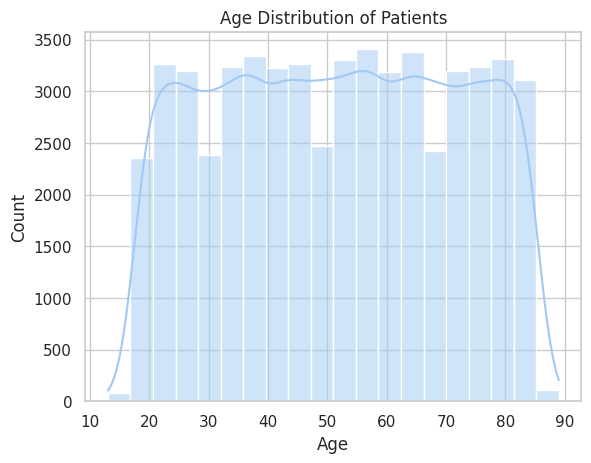

In [ ]:
# Plot the distribution of ages
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# Disease Count

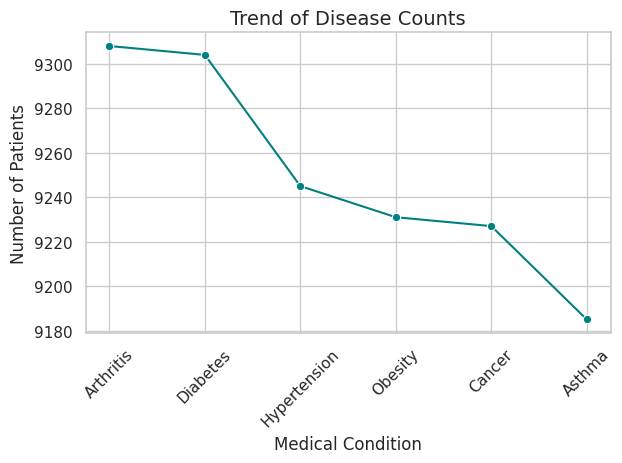

In [ ]:
# Prepare data for line plot
disease_counts = df['Medical Condition'].value_counts().reset_index()
disease_counts.columns = ['Medical Condition', 'Count']

# Line plot
sns.lineplot(
    data=disease_counts,
    x='Medical Condition',
    y='Count',
    marker='o',
    color='teal'
)
plt.title("Trend of Disease Counts", fontsize=14)
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Gender vs Medical Condition


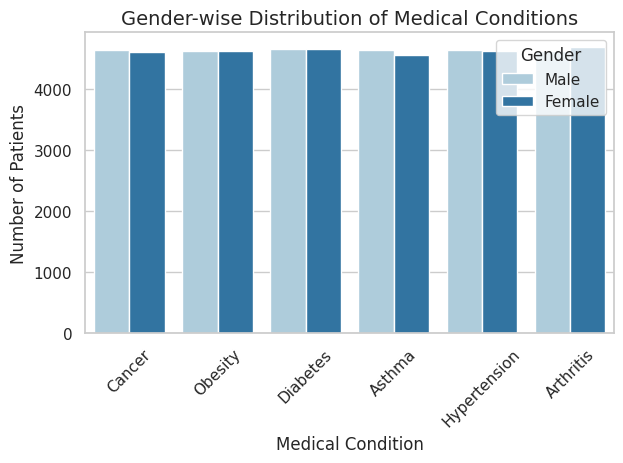

In [ ]:
# Gender vs Disease using countplot (fast & clear)
sns.countplot(
    data=df,
    x='Medical Condition',
    hue='Gender',
    palette='Paired'
)

plt.title("Gender-wise Distribution of Medical Conditions", fontsize=14)
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Which Age Has Which Disease





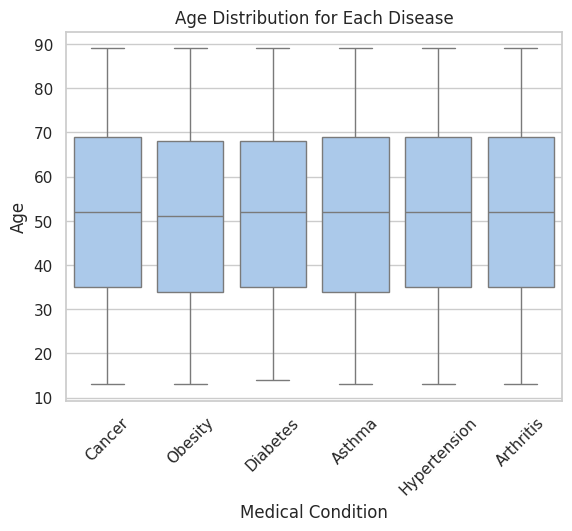

In [ ]:
# Average age for each disease
sns.boxplot(data=df, x='Medical Condition', y='Age')
plt.title("Age Distribution for Each Disease")
plt.xticks(rotation=45)
plt.show()


## Finding the Missing Values


In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


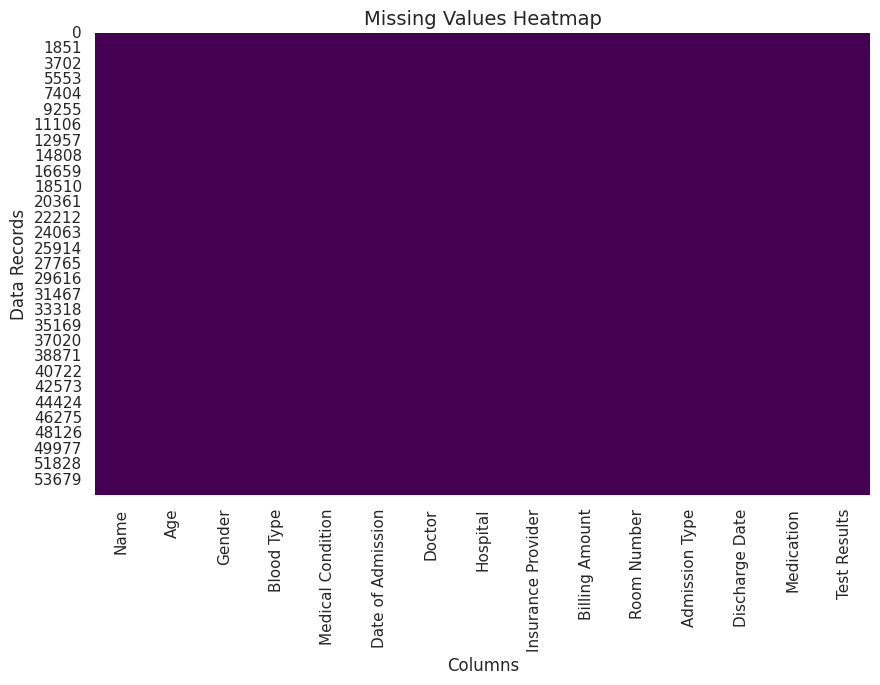

In [ ]:


# Create a boolean mask: True = missing, False = present
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Data Records")
plt.show()


#

# Separating the Numerical and Categorical Columns


In [ ]:
# Separate numerical and categorical columns

# Select numerical columns (int, float)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Select categorical columns (object, string)
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
Index(['Age', 'Billing Amount', 'Room Number'], dtype='object')

Categorical Columns:
Index(['Name', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results'],
      dtype='object')


# Scaling the numerical features

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder


In [ ]:
# Select numerical columns
numerical_cols = ['Age', 'Billing Amount']

# Create a copy to avoid changing the original dataframe
df_scaled = df.copy()

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("✅ Numerical columns scaled successfully!")
df_scaled[numerical_cols].head()

✅ Numerical columns scaled successfully!


,Age,Billing Amount
0,-1.098824,-0.470261
1,0.533639,0.570250
2,1.247842,0.169990
3,-1.200853,0.870465
4,-0.435636,-0.795211


# Encode the Categorical Columns

In [ ]:
# Safe drop version
columns_to_drop = [
    'Name',
    'Date of Admission',
    'Doctor',
    'Hospital',
    'Insurance Provider',
    'Admission Type',
    'Discharge Date',
    'Room Number'
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("✅ Columns after dropping:")
print(df.columns)


✅ Columns after dropping:
Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Billing Amount',
       'Medication', 'Test Results'],
      dtype='object')


In [ ]:
import pandas as pd# Copy from scaled DataFrame
df_encoded = df_scaled.copy()

# Define categorical columns
categorical_columns = ['Gender', 'Blood Type', 'Medical Condition', 'Test Results']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

print("✅ Categorical columns one-hot encoded successfully!")
df_encoded.head()





✅ Categorical columns one-hot encoded successfully!


,Name,Age,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Test Results_Inconclusive,Test Results_Normal
0,Bobby JacksOn,-1.098824,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,-0.470261,328,Urgent,2024-02-02,Paracetamol,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True
1,LesLie TErRy,0.533639,2019-08-20,Samantha Davies,Kim Inc,Medicare,0.570250,265,Emergency,2019-08-26,Ibuprofen,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False
2,DaNnY sMitH,1.247842,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,0.169990,205,Emergency,2022-10-07,Aspirin,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True
3,andrEw waTtS,-1.200853,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,0.870465,450,Elective,2020-12-18,Ibuprofen,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
4,adrIENNE bEll,-0.435636,2022-09-19,Kathleen Hanna,White-White,Aetna,-0.795211,458,Urgent,2022-10-09,Penicillin,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Medication,Test Results
0,30,Male,B-,Cancer,18856.281306,Paracetamol,Normal
1,62,Male,A+,Obesity,33643.327287,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,27955.096079,Aspirin,Normal
3,28,Female,O+,Diabetes,37909.782410,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,14238.317814,Penicillin,Abnormal


# Checking the feature importance

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Drop the target variable
X = df.drop('Billing Amount', axis=1)
y = df['Billing Amount']

# Select categorical columns to encode
categorical_cols_X = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the features
X_encoded = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

# Get feature importance (coefficients for Linear Regression)
importance = pd.Series(model.coef_, index=X_train.columns)
print("\nFeature Importance (Coefficients):")
print(importance.sort_values(ascending=False))


Feature Importance (Coefficients):
Medical Condition_Obesity         317.195427
Medication_Ibuprofen              197.384556
Gender_Male                       177.749489
Medical Condition_Diabetes        118.593283
Blood Type_O-                      90.648224
Test Results_Inconclusive          68.776211
Medical Condition_Hypertension     47.295967
Medical Condition_Asthma           45.861579
Blood Type_AB-                     11.182363
Age                                -6.994931
Medication_Paracetamol            -83.113663
Test Results_Normal              -113.284455
Blood Type_B-                    -152.055102
Medication_Penicillin            -157.001593
Blood Type_A-                    -190.860519
Blood Type_B+                    -295.040542
Medication_Lipitor               -310.603484
Medical Condition_Cancer         -366.812377
Blood Type_AB+                   -431.933053
Blood Type_O+                    -584.916045
dtype: float64


In [ ]:
importance.abs().sort_values(ascending=False)


,0
Blood Type_O+,584.916045
Blood Type_AB+,431.933053
Medical Condition_Cancer,366.812377
Medical Condition_Obesity,317.195427
Medication_Lipitor,310.603484
Blood Type_B+,295.040542
Medication_Ibuprofen,197.384556
Blood Type_A-,190.860519
Gender_Male,177.749489
Medication_Penicillin,157.001593


# Setting the features and the target variable

In [ ]:
# Independent variable (X)
X = df[['Medical Condition']]   # double brackets make it a DataFrame

# Dependent variable (Y)
y = df['Billing Amount']


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)


Coefficient (slope): -6.9949306956180415
Intercept: 26036.330019400462


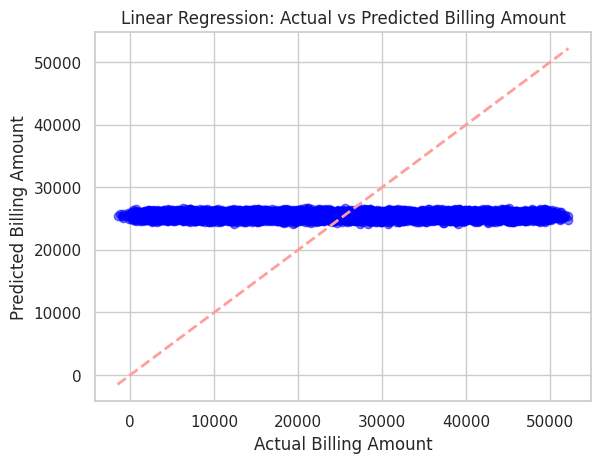

In [ ]:
# Predict billing amount
y_pred = model.predict(X_test)

# Visualize
# Since we have multiple features after encoding, we cannot directly plot against a single 'Medical Condition' column as before.
# We can visualize the actual vs predicted values or residuals instead.
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel('Actual Billing Amount')
plt.ylabel('Predicted Billing Amount')
plt.title('Linear Regression: Actual vs Predicted Billing Amount')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a diagonal line for reference
plt.show()

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first few predictions
print("Predictions:", y_pred[:10])
print("Actual Values:", y_test[:10].values)


Predictions: [25417.82190747 25641.18024337 26031.81709065 25738.24458918
 26136.40372731 25147.34611451 25175.16115129 26056.23543267
 25865.99758559 24949.27069351]
Actual Values: [ 3616.89845    36970.07548148 44393.00134769 27554.92370773
 27466.31856706  4802.62071373 40207.46321828 30065.26059783
   392.91354813 20886.3421484 ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 12191.2746998926
Mean Squared Error (MSE): 199103331.3635155
Root Mean Squared Error (RMSE): 14110.397987424574
R² Score: -0.0009749975457080673


In [ ]:
df.describe(include="all")

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Medication,Test Results
count,55500.000000,55500,55500,55500,55500.000000,55500,55500
unique,NaN,2,8,6,NaN,5,3
top,NaN,Male,A-,Arthritis,NaN,Lipitor,Abnormal
freq,NaN,27774,6969,9308,NaN,11140,18627
mean,51.539459,NaN,NaN,NaN,25539.316097,NaN,NaN
std,19.602454,NaN,NaN,NaN,14211.454431,NaN,NaN
min,13.000000,NaN,NaN,NaN,-2008.492140,NaN,NaN
25%,35.000000,NaN,NaN,NaN,13241.224652,NaN,NaN
50%,52.000000,NaN,NaN,NaN,25538.069376,NaN,NaN
75%,68.000000,NaN,NaN,NaN,37820.508436,NaN,NaN


In [ ]:
df.shape

(55500, 7)

In [ ]:
df.drop_duplicates()

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Medication,Test Results
0,30,Male,B-,Cancer,18856.281306,Paracetamol,Normal
1,62,Male,A+,Obesity,33643.327287,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,27955.096079,Aspirin,Normal
3,28,Female,O+,Diabetes,37909.782410,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,14238.317814,Penicillin,Abnormal
...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,2650.714952,Penicillin,Abnormal
55496,61,Female,AB-,Obesity,31457.797307,Aspirin,Normal
55497,38,Female,B+,Hypertension,27620.764717,Ibuprofen,Abnormal
55498,43,Male,O-,Arthritis,32451.092358,Ibuprofen,Abnormal


In [ ]:
df.dtypes

,0
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Billing Amount,float64
Medication,object
Test Results,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                55500 non-null  int64  
 1   Gender             55500 non-null  object 
 2   Blood Type         55500 non-null  object 
 3   Medical Condition  55500 non-null  object 
 4   Billing Amount     55500 non-null  float64
 5   Medication         55500 non-null  object 
 6   Test Results       55500 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.0+ MB
